# Imports

In [2]:
import os
import sys
import copy
import time
import hashlib
from tqdm import tqdm
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# sys.path.append('/mnt/scripts/biliseq_he_class2') #Maybe should be migrated to wsi_tools
from helpers import preproc as procHelper

%load_ext autoreload
%autoreload 2

dedup = Path('/mnt/data/biliseq_he_class/raw/new_data_20220829')
xlsx_fn = 'Digital Log of Bile Duct Biopsy.xlsx' #Always move?
svs = [str(x.parts[-1]) for x in dedup.glob('*.svs')]
raw = Path('/mnt/data/biliseq_he_class/raw/')
sampleinfo = Path('/mnt/sampleinfo')
results = Path('/mnt/results')
anno = Path('/mnt/data/biliseq_he_class/annotations/')
# fu_df = pd.read_csv(sampleinfo.joinpath('digital_log_bdb_cleaned_bi_435.tsv'),
#                     sep = '\t')

fu_df = pd.read_csv(sampleinfo.joinpath('digital_log_bdb_cleaned_bi_438.csv'),
                    )

info = pd.read_csv(sampleinfo.joinpath('new_data_20220829_diagnosis_data_438_with_anno_v4.tsv'),
                                      sep = '\t')

print(dedup.exists())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
True


# Deidentification / thumbnailing:
see: deident.sh 
see: thumbs .sh

# Generate hashes (new preprocessing step?)

see: helpers/preproc.py 

In [41]:
fn_list = [str(x) for x in dedup.glob('*.svs')]
hash_df = procHelper.filelist_to_hash(fn_list)
# Save it:
fn = 'svs_hash_table_%d.csv' % hash_df.shape[0]
print(fn)
hash_df.to_csv(sampleinfo.joinpath(fn), index =False)
hash_df.head()

100%|██████████| 438/438 [09:14<00:00,  1.27s/it]

554.1476137638092 seconds elapsed


,original_fn,hash_fn,hash_full
0,PHS18-12242 - 1013863.svs,8211312f18aa773080a3c7ea1f1b093d.svs,8211312f18aa773080a3c7ea1f1b093d275e429ebc07d6...
1,PHS19-2477 - 1014035.svs,d8a8d89cad52dae21e3a83a5840b60f1.svs,d8a8d89cad52dae21e3a83a5840b60f1aeb8119102bb98...
2,PHS18-21346 - 1013847.svs,3383cabb683ed87195659e552fa00b6d.svs,3383cabb683ed87195659e552fa00b6d4a8b7b00e6af84...
3,PHS15-4221 - 1011635.svs,a2264cbda48d9189df38e6efab3cdbb4.svs,a2264cbda48d9189df38e6efab3cdbb4685645575feffc...
4,PHS15-9836 - 1007828.svs,67287916bfeb00faf08e5e9e47a788d1.svs,67287916bfeb00faf08e5e9e47a788d1343174fe5692b7...


In [63]:
procHelper.check_dupes(hash_df)

original_fn duplicates: 0
hash_fn duplicates: 0
hash_full duplicates: 0


In [50]:
fn = 'svs_hash_table_%d.csv' % hash_df.shape[0]
print(fn)
hash_df.to_csv(sampleinfo.joinpath(fn), index =False)

svs_hash_table_438.csv


# Show putative duplicates

In [2]:
info=pd.read_excel(dedup.joinpath(xlsx_fn))

#Fix typo:
typo = info.loc[:,'Accession Number'].str.contains('PHS20-99 - 1 - 1911901')
info.loc[typo,'Accession Number'] = 'PHS20-99 - 1 - 1011901'

print(info.loc[:,'Pathologic Diagnosis'].unique())
temp = info.loc[:,'Accession Number'].str.replace('--','-')
temp = temp.str.replace('  ',' ')
temp = temp.str.replace(' -',' - ')
keep = []
remove = []
count = 0
for i,num in enumerate(temp.str.split(' - ').values):
    n = num[-1].replace(' ','')
    if 'Malignant' in n:
        n = num[-2].replace(' ','')
    if 'PHS' in n: #Indicates no slide number, i.e. a duplicate in this dataset
        print('"%s"' % temp[i], end=', ')
        count = count + 1
print('\n')
print(count)

['Adenocarcinoma' 'Negative for Adenocarcinoma' 'Low-Grade Adenoma']
"PHS15-1587", "PHS15-2282", "PHS15-3190", "PHS15-21705", "PHS15-23649", "PHS15-28451", "PHS15-28803", "PHS15-34010", "PHS15-34075", "PHS15-42791", "PHS15-44776", "PHS21-40884", "PHS22-1441", "PHS22-1966", "PHS22-6356", "PHS22-6651", "PHS22-8184", "PHS20-8394", "PHS20-27166", "PHS20-36578", "PHS21-1568", "PHS21-2840", 

22


In [4]:
print(info.shape, fu_df.shape)

(454, 4) (435, 11)


In [12]:
fu_df.head()

,accession_number,pathologic_diagnosis,dob,location,follow_up_diagnosis,notes,phs,section_num,slide_num,fu_pos,path_pos
0,EAS20-6314 - 1013820,Adenocarcinoma,1958-07-28,Distal,Duodenal Adenocarcinoma,NaN,EAS20-6314,NaN,1013820,True,True
1,MYS20-128 - 1 - 1013755,Adenocarcinoma,1937-06-10,Mid,Intrahepatic Cholangiocarcinoma,NaN,MYS20-128,1.0,1013755,True,True
2,MYS20-128 - 2 -1013757,Adenocarcinoma,1937-06-10,Mid,Intrahepatic Cholangiocarcinoma,NaN,MYS20-128,2.0,1013757,True,True
3,MYS20-128 - 3 - 1013756,Adenocarcinoma,1937-06-10,Mid,Intrahepatic Cholangiocarcinoma,NaN,MYS20-128,3.0,1013756,True,True
4,MYS20-293 - 1013761,Negative for Adenocarcinoma,1959-03-12,Distal,Benign Stricture,NaN,MYS20-293,NaN,1013761,False,False


In [26]:
not_multi = fu_df.section_num.isna()
mal = fu_df.fu_pos

print('Malignant',mal.sum(), '| Multi slide ratio:', mal.sum() / len(fu_df.phs[mal.values].unique()))
print('Malignant multi-slide total:',  np.sum((~not_multi) & mal.values))
print('Not multi mal:', np.sum(not_multi.values & mal.values), 
      'Unique:', len(fu_df.phs[mal.values].unique()))
print('')
ben = fu_df.fu_pos.values == False
print('Benign',np.sum(ben), '| Multi slide ratio:', np.sum(ben) / len(fu_df.phs[ben].unique()))
print('Benign multi-slide total:', np.sum((~not_multi) & ben))


print('Not multi ben:', np.sum(not_multi.values & ben), 'Unique:',len(fu_df.phs[ben].unique()))



Malignant 246 | Multi slide ratio: 1.4057142857142857
Malignant multi-slide total: 99
Not multi mal: 147 Unique: 175

Benign 189 | Multi slide ratio: 1.0617977528089888
Benign multi-slide total: 16
Not multi ben: 173 Unique: 178


In [10]:
99 / fu_df.shape[0]

0.22758620689655173

In [14]:
99/115

0.8608695652173913

In [12]:
np.sum((~not_multi) & ben) (16 slides


16

# Clean diagnosis table, deduplicate

In [64]:
info=pd.read_excel(dedup.joinpath(xlsx_fn))

#Fix typos:
typo = info.loc[:,'Accession Number'].str.contains('PHS20-99 - 1 - 1911901')
info.loc[typo,'Accession Number'] = 'PHS20-99 - 1 - 1011901'

typo = info.loc[:,'Accession Number'].str.contains('PHS19-27841 - 1013788')
info.loc[typo,'Accession Number'] = 'PHS19-27841 - 1013799'

typo = info.loc[:,'Accession Number'].str.contains('PHS15-42791 - 1011638') # PHS15-42791 - 1011630
info.loc[typo,'Accession Number'] = 'PHS15-42791 - 1011630'


print(info.loc[:,'Pathologic Diagnosis'].unique())
temp = info.loc[:,'Accession Number'].str.replace('--','-')
temp = temp.str.replace('  ',' ')
temp = temp.str.replace(' -',' - ')
keep=[]
remove=[]
for i,num in enumerate(temp.str.split(' - ').values):
    n = num[-1].replace(' ','')
    if 'Malignant' in n:
        n = num[-2].replace(' ','')
    if 'PHS' in n: #Indicates no slide number, i.e. a duplicate in this dataset
        remove.append(i)
    keep.append(n)
cols = info.columns.str.replace(' ','_').str.lower()
info.columns=cols
print(cols)
info.loc[:,'slide_num'] = keep
info.loc[remove,:] = np.nan
info = info.dropna(how='all').reset_index(drop=True)
fn = sampleinfo.joinpath('new_data_20220829_diagnosis_data.tsv')
print(info.shape)   
info.to_csv(fn, sep='\t')
print(fn)
info.head()


['Adenocarcinoma' 'Negative for Adenocarcinoma' 'Low-Grade Adenoma']
Index(['accession_number', 'pathologic_diagnosis', 'follow-up_diagnosis',
       'notes'],
      dtype='object')
(432, 5)
/mnt/sampleinfo/new_data_20220829_diagnosis_data.tsv


,accession_number,pathologic_diagnosis,follow-up_diagnosis,notes,slide_num
0,EAS20-6314 - 1013820,Adenocarcinoma,Duodenal Adenocarcinoma,NaN,1013820
1,MYS20-128 - 1 - 1013755,Adenocarcinoma,Cholangiocarcinoma,NaN,1013755
2,MYS20-128 - 2 -1013757,Adenocarcinoma,Cholangiocarcinoma,NaN,1013757
3,MYS20-128 - 3 - 1013756,Adenocarcinoma,Cholangiocarcinoma,NaN,1013756
4,MYS20-293 - 1013761,Negative for Adenocarcinoma,NaN,NaN,1013761


In [62]:
for i,slide in enumerate(info.slide_num):
    if 'PHS' in slide:
        #There should be none!
        print(info.accession_number[i])
    if 'Malignant' in slide:
        #There should be none!
        print(info.accession_number[i])
    if 'PHS20-99' in info.accession_number[i]:
        #Confusing labeling
        print(info.accession_number[i])

PHS20-99 - 1 - 1011901
PHS20-99 - 2 - 1011896
PHS20-99 - 3 - 1011892
PHS20-99 - 4 - 1012220
PHS20-99 - 5 - 1012008


# Load info

In [5]:
# fn = sampleinfo.joinpath('new_data_20220829_diagnosis_data.tsv')
fn = sampleinfo.joinpath('new_data_20220829_diagnosis_data_with_anno_v2.tsv')
info = pd.read_csv(fn,sep='\t')
anno = info.loc[:,('accession_number','slide_num','anno_class')].dropna(how='any').reset_index(drop=True)
anno.head()

,accession_number,slide_num,anno_class
0,PHS15-7377 - 1007831,1007831,malignant
1,PHS15-7510 - 1010330,1010330,benign
2,PHS15-9836 - 1007828,1007828,malignant
3,PHS15-29884 - 1010333,1010333,benign
4,PHS16-5752 - 1010328,1010328,benign


In [30]:
# Are all .svs in new_data_20220829? Possibly yes.
for f in svs:
    if 'PHS22-6651' in f: #Found: suggests new_data_20220627 are also in new_data_20220829
        print('new_data_20220627:',f)
    elif '1010328' in f: #Found: suggests new_test_data images are also in new_data_20220829
        print('new_test_data:',f)
    elif '1007820' in f: #Found: suggests original dataset images are also in new_data_20220829
        print('original dataset:',f)
    elif '1010278' in f:
        print('Neg-MFU:',f)

new_test_data: PHS16-5752 - 1010328.svs
original dataset: PHS17-23147 - 1007820.svs
Neg-MFU: PHS21-32135 - 1010278 - Malignant FU.svs
new_data_20220627: PHS22-6651 - 1011488.svs


In [65]:
dedup_fns = []
for f in svs:
    if ' - ' not in f:
        
        for ff in svs:            
            if f.split('.')[0] in ff:            
                if ' - ' in ff:
                    print('keep:',ff)
                    print('remove',f)
                    # os.remove(dedup.joinpath(f))
                    # dedup_fns.append(f)
                    


# Load in & clean pathology vs. followup diagnosis table:

In [56]:
fn = sampleinfo.joinpath('Digital Log of Bile Duct Biopsies.xlsx')
fu_df = pd.read_excel(fn)
fu_df.head()

typo = fu_df.loc[:,'Accession Number'].str.contains('PHS20-99 - 1 - 1911901')
fu_df.loc[typo,'Accession Number'] = 'PHS20-99 - 1 - 1011901'

typo = fu_df.loc[:,'Accession Number'].str.contains('PHS19-27841 - 1013788')
fu_df.loc[typo,'Accession Number'] = 'PHS19-27841 - 1013799'

typo = fu_df.loc[:,'Accession Number'].str.contains('PHS15-42791 - 1011638') # PHS15-42791 - 1011630
fu_df.loc[typo,'Accession Number'] = 'PHS15-42791 - 1011630'


print(fu_df.loc[:,'Pathologic Diagnosis'].unique())
print(fu_df.loc[:,'Follow-up Diagnosis'].unique())

temp = fu_df.loc[:,'Accession Number'].str.replace('--','-')
temp = temp.str.replace('  ',' ')
temp = temp.str.replace(' -',' - ')
temp = temp.str.replace('- ',' - ')
keep = []
remove = []
dupe = []
has_multi = []
section = []
phs = []

for i,num in enumerate(temp.str.split(' - ').values):
    n = num[-1].replace(' ','')
    if 'Malignant' in n:
        n = num[-2].replace(' ','')
    if 'PHS' in n: #Indicates no slide number,
        how_many = temp.str.contains(n).sum()
        if how_many > 1: # indicates duplicate w/ entry that does have slide number
            remove.append(i)
            both = np.argwhere(temp.str.contains(n).values).flatten()
            dupe.append(both[both != i][0])
    phs.append(num[0])
    if len(num) == 3:
        #May contain multiple slides from same patient
        if 'Malignant FU' not in num[2]:
            has_multi.append(i)
            section.append(num[1])    
    keep.append(n)
cols = fu_df.columns.str.replace(' ','_').str.replace('-','_').str.lower()
print('N slides that are multiples, i.e. coming from same phs:', len(has_multi))
print(cols)
fu_df.columns=cols

fu_df.loc[:,'phs']=phs
fu_df.loc[has_multi,'section_num']=section
fu_df.loc[:,'slide_num'] = keep
fu_df.loc[remove,:] = np.nan
fu_df = fu_df.dropna(how='all').reset_index(drop=True)
fu_df = fu_df.drop(columns=['accession_number.1','unnamed:_2'])
fu_pos = fu_df.follow_up_diagnosis.str.contains('arcinoma') | \
         fu_df.follow_up_diagnosis.str.contains('Cancer') 
         # fu_df.follow_up_diagnosis.str.contains('Malignant')
fu_df.loc[:,'fu_pos'] = fu_pos
fu_df.loc[:,'path_pos'] = fu_df.pathologic_diagnosis.str.match('Adenocarcinoma')
fa = fu_df.path_pos.values & ~fu_df.fu_pos.values 
miss = ~fu_df.path_pos.values &  fu_df.fu_pos.values
print('%d FU neg and path pos' % np.sum(fa))
print('%d FU pos and path neg' % np.sum(miss))
fn = sampleinfo.joinpath('digital_log_bdb_cleaned_bi_%d.tsv' % fu_df.shape[0])
print(fn)
fu_df.to_csv(fn, sep = '\t', index =False)


['Adenocarcinoma' 'Negative for Adenocarcinoma' 'Low-Grade Adenoma']
['Duodenal Adenocarcinoma' 'Intrahepatic Cholangiocarcinoma'
 'Benign Stricture' 'Extrahepatic Cholangiocarcinoma'
 'Pancreatic Ductal Adenocarcinoma' 'Ampullary Adenocarcinoma'
 'High-grade dysplasia' 'Gallbladder Adenocarcinoma'
 'Benign Stricture - Malignant Lymphoma - Not Epithelial' 'Adenoma'
 'Metastatic Colon Cancer' 'Metastatic Gastric Cancer'
 'Metastatic Ovariant Carcinoma']
N slides that are multiples, i.e. coming from same phs: 115
Index(['accession_number', 'accession_number.1', 'unnamed:_2',
       'pathologic_diagnosis', 'dob', 'location', 'follow_up_diagnosis',
       'notes'],
      dtype='object')
0 FU neg and path pos
93 FU pos and path neg
/mnt/sampleinfo/digital_log_bdb_cleaned_bi_435.tsv


In [78]:
fu_df.loc[~fu_df.loc[:,'section_num'].isna(),:].head()

,accession_number,pathologic_diagnosis,dob,location,follow_up_diagnosis,notes,phs,section_num,slide_num,fu_pos,path_pos
1,MYS20-128 - 1 - 1013755,Adenocarcinoma,1937-06-10,Mid,Intrahepatic Cholangiocarcinoma,NaN,MYS20-128,1,1013755,True,True
2,MYS20-128 - 2 -1013757,Adenocarcinoma,1937-06-10,Mid,Intrahepatic Cholangiocarcinoma,NaN,MYS20-128,2,1013757,True,True
3,MYS20-128 - 3 - 1013756,Adenocarcinoma,1937-06-10,Mid,Intrahepatic Cholangiocarcinoma,NaN,MYS20-128,3,1013756,True,True
10,MYS20-1531 - 1 - 370301,Adenocarcinoma,1945-09-08,Distal,Extrahepatic Cholangiocarcinoma,NaN,MYS20-1531,1,370301,True,True
11,MYS20-1531 - 2 - 370307,Adenocarcinoma,1945-09-08,Distal,Extrahepatic Cholangiocarcinoma,NaN,MYS20-1531,2,370307,True,True


In [82]:
np.max(fu_df.loc[:,'section_num'].dropna().values)

' 9 '

In [67]:
fu_df.phs[~fu_df.loc[:,'section_num'].isna()].unique().shape[0] + \
fu_df.phs[fu_df.loc[:,'section_num'].isna()].unique().shape[0]


353

In [69]:
sensitivity = 1 - (len(fu_df.loc[miss,'phs'].unique()) / len(fu_df.loc[:,'phs'].unique()))
print(sensitivity)

0.7847025495750708


In [116]:
fu_df.notes.dropna().unique()

array(['PSC', '2ndary to Ampullary Adenoma', 'IPMN associated', 'HER2 3+',
       'Autoimmune pancreatitis', 'Villous like',
       'GNAS mutation at first biopsy',
       'Low-level KRAS but not diagnosed til mid 2019; Careanywhere',
       'Low level TP53',
       'However, previous history of gallbladder cancer', 'Sampling',
       'Neuroendocrine Carcinoma', 'Ampullary Adenoma (LGD)',
       'PHS19-30894', 'Pancreatitis',
       'MSI-H (potentially hypermethylation)', 'IDH1', 'U2AF1', '?ITPN',
       'ERBB2 amplified', 'previous KRAS', 'MSI-H Lynch syndrome', 'IPNB',
       'Chronic Pancreatitis', 'CHIP IDH2 mutations'], dtype=object)

In [119]:
sub = fu_df.loc[:,['accession_number','notes','pathologic_diagnosis','follow_up_diagnosis']].dropna(how='any')
sub.loc[sub.notes.str.contains('creatitis'),:]

,accession_number,notes,pathologic_diagnosis,follow_up_diagnosis
52,PHS16-19238 - 1007825,Autoimmune pancreatitis,Negative for Adenocarcinoma,Benign Stricture
97,PHS18-10949 - 1013838,Autoimmune pancreatitis,Negative for Adenocarcinoma,Benign Stricture
258,PHS21-22367 - 1010282,Pancreatitis,Negative for Adenocarcinoma,Benign Stricture
311,PHS20-9179 - 1014085,Autoimmune pancreatitis,Negative for Adenocarcinoma,Benign Stricture
362,PHS20-24381 - 1013907,Chronic Pancreatitis,Negative for Adenocarcinoma,Benign Stricture
363,PHS20-25176 - 1007470,Chronic Pancreatitis,Negative for Adenocarcinoma,Benign Stricture
384,PHS20-27880 - 1007469,Pancreatitis,Negative for Adenocarcinoma,Benign Stricture
421,PHS21-408 - 1007846,Chronic Pancreatitis,Negative for Adenocarcinoma,Benign Stricture


# Include code for running tiling

In [ ]:
%%bash
# Should add location of log file destination .. e.g. /mnt/logs/v8/tiling/run12092022
SRC_PATH=/mnt/data/biliseq_he_class/raw/new_data_20220829
DEST_PATH=/mnt/results
PROJ_MNT=/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2
SING_IMG=/ix/rbao/images/pathml_jupyter.sif
SING_EXEC_SCRIPT=/mnt/scripts/biliseq_he_class2/preprocessing/pathml_preproc_v8.py
SAMPLE_INFO=/mnt/sampleinfo/new_data_20220829_diagnosis_data_438_with_anno_v4.tsv #new_data_20220829_diagnosis_data_with_anno_v3.tsv
JOB_SCRIPT=$PROJ_MNT/scripts/biliseq_he_class2/preprocessing/proc_job_v8.sh


START=0
STOP=432
# for --array=$START-$STOP
RERUN="435,436,437" #Slide number typos & new slides
TILE_SIZE=224
echo "Beginning" $TILE_SIZE "px batch process... on jobs" $START "to" $STOP
sbatch --array=$RERUN \
        $JOB_SCRIPT \
        $SRC_PATH \
        $DEST_PATH \
        $PROJ_MNT \
        $SING_IMG \
        $SING_EXEC_SCRIPT \
        $SAMPLE_INFO \
        $TILE_SIZE
echo "Batch sent!"


# After a tiling run, determine slides with errors that need to be rerun

In [4]:
# Original way sampleinfo table was generated:
oldinfo=pd.read_excel(dedup.joinpath(xlsx_fn))
temp = oldinfo.loc[:,'Accession Number'].str.replace('--','-')
temp = temp.str.replace('  ',' ')
temp = temp.str.replace(' -',' - ')
keep=[]
remove=[]
for i,num in enumerate(temp.str.split(' - ').values):
    n = num[-1].replace(' ','')
    keep.append(n)
cols = oldinfo.columns.str.replace(' ','_').str.lower()
oldinfo.columns=cols
print(cols)
oldinfo.loc[:,'slide_num'] = keep
oldinfo.to_csv(sampleinfo.joinpath('run0_new_data_20220829_diagnosis_data.tsv'),
              sep='\t')

Index(['accession_number', 'pathologic_diagnosis', 'follow-up_diagnosis',
       'notes'],
      dtype='object')


In [98]:
log = Path('/mnt/logs')
errs = log.joinpath('v8_all_errors.txt')
mfu = pd.read_csv(errs, sep=':', header=None,usecols=[0])
allerrs=[]
print('List of all issues:\n')
an = []
for logfn in mfu.iloc[:,0].values:
    bad_index = int(logfn.split('_')[1].split('.')[0])
    allerrs.append(bad_index)
    ba = oldinfo.loc[bad_index,'accession_number']
    an.append(ba)
    print('%d  %s' % (bad_index,ba))
# print('\n'.join(oldinfo.loc[allerrs,'accession_number'].unique()))
print('\nJob indices of errors in old sampleinfo file:')
print('old indices: [',','.join([str(x) for x in np.unique(allerrs)]),']')
an = an + ['PHS20-99 - 1 - 1011901']
newa = np.argwhere(info.accession_number.isin(an).values).flatten()
print('new indices: [', ','.join([str(x) for x in newa]),']')
# print('New indicies:',newa)

List of all issues:

34  PHS15-19669 - 1007822 - Malignant FU
260  PHS20-99 - 1 - 1911901
284  PHS21-38842 - 1010284 - Malignant FU
65  PHS16-20890 - 1010932 - Malignant FU
285  PHS21-38708 - 1010283 - Malignant FU
62  PHS16-15556 - 1010617
62  PHS16-15556 - 1010617
401  PHS20-27474 - 1007466 - Malignant FU
276  PHS21-30516 - 1010280 - Malignant FU
278  PHS21-32135 - 1010278 - Malignant FU
59  PHS16-2137 - 1010327 - Malignant FU
75  PHS17-10214 - 1007824 - Malignant FU
401  PHS20-27474 - 1007466 - Malignant FU
285  PHS21-38708 - 1010283 - Malignant FU
276  PHS21-30516 - 1010280 - Malignant FU
278  PHS21-32135 - 1010278 - Malignant FU
260  PHS20-99 - 1 - 1911901
64  PHS16-20223 - 1010329 - Malignant FU
284  PHS21-38842 - 1010284 - Malignant FU
75  PHS17-10214 - 1007824 - Malignant FU
64  PHS16-20223 - 1010329 - Malignant FU
34  PHS15-19669 - 1007822 - Malignant FU
59  PHS16-2137 - 1010327 - Malignant FU
65  PHS16-20890 - 1010932 - Malignant FU
62  PHS16-15556 - 1010617
62  PHS16-15556 -

# After tiling run, look for missing slides

In [74]:
missing = []
mn = []
for i,x in enumerate(fu_df.slide_num):
    tpn = results.joinpath('v8/tiles/224px').joinpath(str(x))
    if tpn.exists() == False:
        missing.append(str(x))
        mn.append(i)
print(missing)
print('new indices: [', ','.join([str(x) for x in mn]),']')

['1011630', '1011638', '1013799', '1013788', '837684', '837691', '837695']
new indices: [ 42,45,212,225,432,433,434 ]


# Finding other mismatches in slide name vs. table

In [62]:
t =dedup.rglob('*.svs')
matching = []
for f in t:
    fn = f.parts[-1].split('.svs')[0]
    template = fn
    match = 0
    for slide in fu_df.slide_num.values:            
        if str(slide) in template:   
            match = slide
            matching.append(template)
            # print(template,'==',slide)
    if match == 0:
        print('Missing match:', template)
        # print(

for slide in fu_df.slide_num.values:
    match = '0'
    t =dedup.rglob('*.svs')
    for f in t:
        template =  f.parts[-1].split('.svs')[0]        
        if slide in template:
            match = slide
            # print(template,str(slide))
    if match == '0':
        print('Entry in table has no slide:', slide)
        print(fu_df.loc[fu_df.slide_num == slide,'accession_number'])
    
# print(len(matching),fu_df.shape)

In [16]:
# print(fu_df.loc[fu_df.accession_number.str.contains('PHS19-27841'),:])
fu_df.loc[fu_df.accession_number.str.contains('PHS15-42791'),:]

,accession_number,pathologic_diagnosis,dob,location,follow_up_diagnosis,notes,phs,section_num,slide_num,fu_pos,path_pos
42,PHS15-42791 - 1011638,Negative for Adenocarcinoma,1947-07-25,Distal,Benign Stricture,NaN,PHS15-42791,NaN,1011638,False,False


# Look at max wall time of tiling:

Text(0.5, 1.0, 'Max time = 3.9 hours')

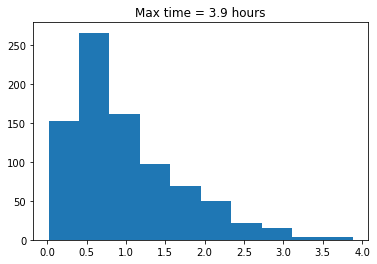

In [71]:
walltimes = pd.read_csv(log.joinpath('v8_tile_walltimes.txt'),
                        engine='python',
                        sep=':Wall time = ',
                        header = None)
all_wt=[]
for wt in walltimes.iloc[:,1]:
    H=int(wt.split(':')[0])
    M=int(wt.split(':')[1])/60
    all_wt.append(H+M)
plt.hist(all_wt)
plt.title('Max time = %1.1f hours' % np.max(all_wt))

# Match annotation files to file names in main raw .svs folder, save in sampleinfo

In [9]:
tile_path[0]

'1007476'

In [40]:
anno = Path('/mnt/data/biliseq_he_class/annotations/')
tile = results.joinpath('v8/tiles/224px')
print(tile.exists())
t = anno.rglob('*.svs.geojson')
missing = []
anno_info = {'anno_fn':[],
             'anno_class':[],
             'raw_fn':[],
             'anno_pnfn':[],
             'tile_pn': [],
             'slide_num':[]
            }
for f in t:
    fn = f.parts[-1].split('.svs')[0]
    missing.append(fn)
    for ff in svs:            
        if fn in str(ff):   
            if 'PHS22-23675' in fn:
                print(fn,'-->',ff)
            #Find tile path:
            use = ff.split('.')[0]
            idx1 = info.slide_num.str.contains(use)
            idx2 = info.accession_number.str.contains(use)
            tile_path='NA'
            if not np.any(idx1 | idx2):
                print('%s missing' % use)
            elif np.sum(idx1 | idx2) > 1:
                print('Warning %d different slide matches' % np.sum(idx1 | idx2))
            else:
                idx = idx1 | idx2
                tile_path = info.slide_num[idx].values[0]
            anno_info['anno_fn'].append(fn)
            anno_info['anno_class'].append(f.parts[-2].split('_')[0])
            anno_info['anno_pnfn'].append(str(f))
            anno_info['raw_fn'].append(ff)    
            anno_info['slide_num'].append(tile_path)
            full_tile_path = tile.joinpath(tile_path)
            if full_tile_path.exists():
                anno_info['tile_pn'].append(str(full_tile_path))
            else:
                anno_info['tile_pn'].append('NA')
            missing.pop()
                
print('missing: ',len(missing))
print(missing)
ai = pd.DataFrame(anno_info)
fn = 'annotated_fns_v2.tsv'
ai.to_csv(sampleinfo.joinpath(fn),
          sep='\t')
print(sampleinfo.joinpath(fn))
ai.loc[ai.anno_class.str.contains('multi'),:]

True
PHS22-23675 - 1 - 9 --> PHS22-23675 - 1 - 9.svs
PHS22-23675 - 1 - 2 --> PHS22-23675 - 1 - 2.svs
PHS22-23675 - 1 - 1 --> PHS22-23675 - 1 - 1.svs
missing:  0
[]
/mnt/sampleinfo/annotated_fns_v2.tsv


,anno_fn,anno_class,raw_fn,anno_pnfn,tile_pn,slide_num
18,PHS20-25327 - 7 - 367642,multi,PHS20-25327 - 7 - 367642.svs,/mnt/data/biliseq_he_class/annotations/multi_s...,/mnt/results/v8/tiles/224px/367642,367642
19,PHS20-25327 - 10 - 367651,multi,PHS20-25327 - 10 - 367651.svs,/mnt/data/biliseq_he_class/annotations/multi_s...,/mnt/results/v8/tiles/224px/367651,367651
20,PHS20-32867 - 7 - 413751,multi,PHS20-32867 - 7 - 413751.svs,/mnt/data/biliseq_he_class/annotations/multi_s...,/mnt/results/v8/tiles/224px/413751,413751
21,PHS20-32867 - 6 - 413748,multi,PHS20-32867 - 6 - 413748.svs,/mnt/data/biliseq_he_class/annotations/multi_s...,/mnt/results/v8/tiles/224px/413748,413748
22,PHS22-23675 - 1 - 9,multi,PHS22-23675 - 1 - 9.svs,/mnt/data/biliseq_he_class/annotations/multi_s...,/mnt/results/v8/tiles/224px/PHS22-23675 - 1 - 9,PHS22-23675 - 1 - 9
23,PHS20-32867 - 5 - 413746,multi,PHS20-32867 - 5 - 413746.svs,/mnt/data/biliseq_he_class/annotations/multi_s...,/mnt/results/v8/tiles/224px/413746,413746
24,PHS20-9658 - 4 - 1014131,multi,PHS20-9658 - 4 - 1014131.svs,/mnt/data/biliseq_he_class/annotations/multi_s...,/mnt/results/v8/tiles/224px/1014131,1014131
25,PHS20-25327 - 5 - 367637,multi,PHS20-25327 - 5 - 367637.svs,/mnt/data/biliseq_he_class/annotations/multi_s...,/mnt/results/v8/tiles/224px/367637,367637
26,PHS20-32867 - 2 - 409703,multi,PHS20-32867 - 2 - 409703.svs,/mnt/data/biliseq_he_class/annotations/multi_s...,/mnt/results/v8/tiles/224px/409703,409703
27,PHS20-32867 - 8 - 413752,multi,PHS20-32867 - 8 - 413752.svs,/mnt/data/biliseq_he_class/annotations/multi_s...,/mnt/results/v8/tiles/224px/413752,413752


In [13]:
np.any(ai.anno_pnfn.str.contains('NA'))

False

# Save version of info with slides that have annotations indicated

In [32]:
ai.columns

Index(['anno_fn', 'anno_class', 'raw_fn', 'anno_pnfn', 'tile_pn'], dtype='object')

In [37]:
ai.head()

,anno_class,anno_pnfn,tile_pn,slide_num
0,malignant,/mnt/data/biliseq_he_class/annotations/maligna...,/mnt/results/v8/tiles/224px/1007476,1007476
1,malignant,/mnt/data/biliseq_he_class/annotations/maligna...,/mnt/results/v8/tiles/224px/1007731,1007731
2,malignant,/mnt/data/biliseq_he_class/annotations/maligna...,/mnt/results/v8/tiles/224px/1007482,1007482
3,malignant,/mnt/data/biliseq_he_class/annotations/maligna...,/mnt/results/v8/tiles/224px/1007831,1007831
4,malignant,/mnt/data/biliseq_he_class/annotations/maligna...,/mnt/results/v8/tiles/224px/1007733,1007733


In [34]:
temp =  pd.read_csv(sampleinfo.joinpath('digital_log_bdb_cleaned_bi_438.csv'))
temp.columns

Index(['accession_number', 'pathologic_diagnosis', 'dob', 'location',
       'follow_up_diagnosis', 'notes', 'phs', 'section_num', 'slide_num',
       'fu_pos', 'path_pos'],
      dtype='object')

In [3]:
info_new = pd.read_csv(sampleinfo.joinpath('digital_log_bdb_cleaned_bi_438.csv'))
info_new.loc[info_new.phs.isna(),'accession_number'].values[0].split(' - ')[0]

'PHS19-819'

In [4]:
# ai = pd.read_csv(sampleinfo.joinpath('annotated_fns_v0.tsv'),sep='\t').drop(columns='Unnamed: 0')
ai = pd.read_csv(sampleinfo.joinpath('annotated_fns_v2.tsv'),sep='\t').drop(columns='Unnamed: 0')

# ai = ai.drop(columns=['anno_fn','raw_fn'])

info_new = pd.read_csv(sampleinfo.joinpath('digital_log_bdb_cleaned_bi_438.csv'))
info_new.loc[info_new.phs.isna(),'phs'] = info_new.loc[info_new.phs.isna(),'accession_number'].values[0].split(' - ')[0]
# info_new = info.drop(columns=['anno_class','anno_pnfn'])
                     
tt = pd.merge(info_new,ai,on='slide_num',how='left')
tt = tt.loc[~tt.accession_number.duplicated(),:].reset_index(drop=True)

new_fn = 'new_data_20220829_diagnosis_data_%d_with_anno_v4.tsv' % tt.shape[0]
print(new_fn)

tt.to_csv(sampleinfo.joinpath(new_fn),
                              sep = '\t',
                              index = False)
# tt.loc[~tt.anno_class.isna() & tt.anno_class.str.contains('multi'),:]
tt.head()

new_data_20220829_diagnosis_data_438_with_anno_v4.tsv


,accession_number,pathologic_diagnosis,dob,location,follow_up_diagnosis,notes,phs,section_num,slide_num,fu_pos,path_pos,anno_fn,anno_class,raw_fn,anno_pnfn,tile_pn
0,EAS20-6314 - 1013820,Adenocarcinoma,7/28/1958,Distal,Duodenal Adenocarcinoma,NaN,EAS20-6314,NaN,1013820,True,True,NaN,NaN,NaN,NaN,NaN
1,MYS20-128 - 1 - 1013755,Adenocarcinoma,6/10/1937,Mid,Intrahepatic Cholangiocarcinoma,NaN,MYS20-128,1.0,1013755,True,True,NaN,NaN,NaN,NaN,NaN
2,MYS20-128 - 2 -1013757,Adenocarcinoma,6/10/1937,Mid,Intrahepatic Cholangiocarcinoma,NaN,MYS20-128,2.0,1013757,True,True,NaN,NaN,NaN,NaN,NaN
3,MYS20-128 - 3 - 1013756,Adenocarcinoma,6/10/1937,Mid,Intrahepatic Cholangiocarcinoma,NaN,MYS20-128,3.0,1013756,True,True,NaN,NaN,NaN,NaN,NaN
4,MYS20-293 - 1013761,Negative for Adenocarcinoma,3/12/1959,Distal,Benign Stricture,NaN,MYS20-293,NaN,1013761,False,False,NaN,NaN,NaN,NaN,NaN


In [5]:
sum(tt.phs.isna())

0